Video Width: 464
Video Height: 832
Frame Rate: 59
Total Extracted Frames: 18

Frame | Blur Before | Blur After
------------------------------------------------
frame_0000.jpg | 2789.68 | 6011.19


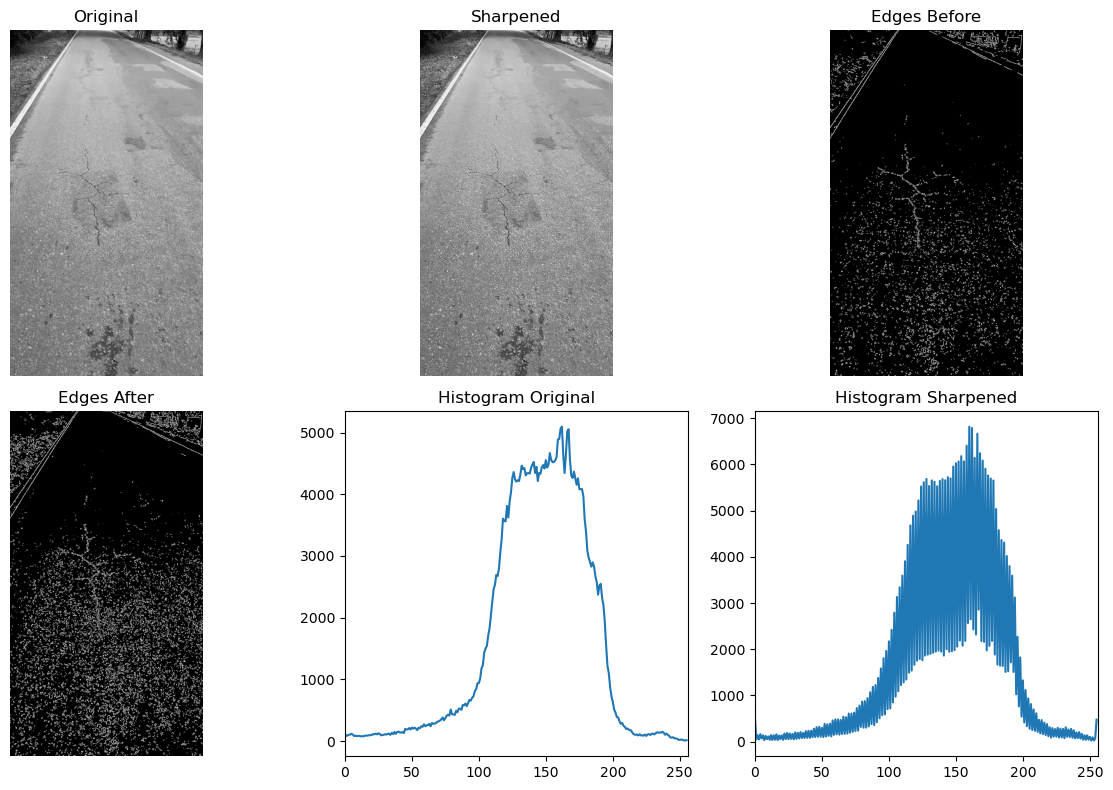

frame_0001.jpg | 574.06 | 1154.82


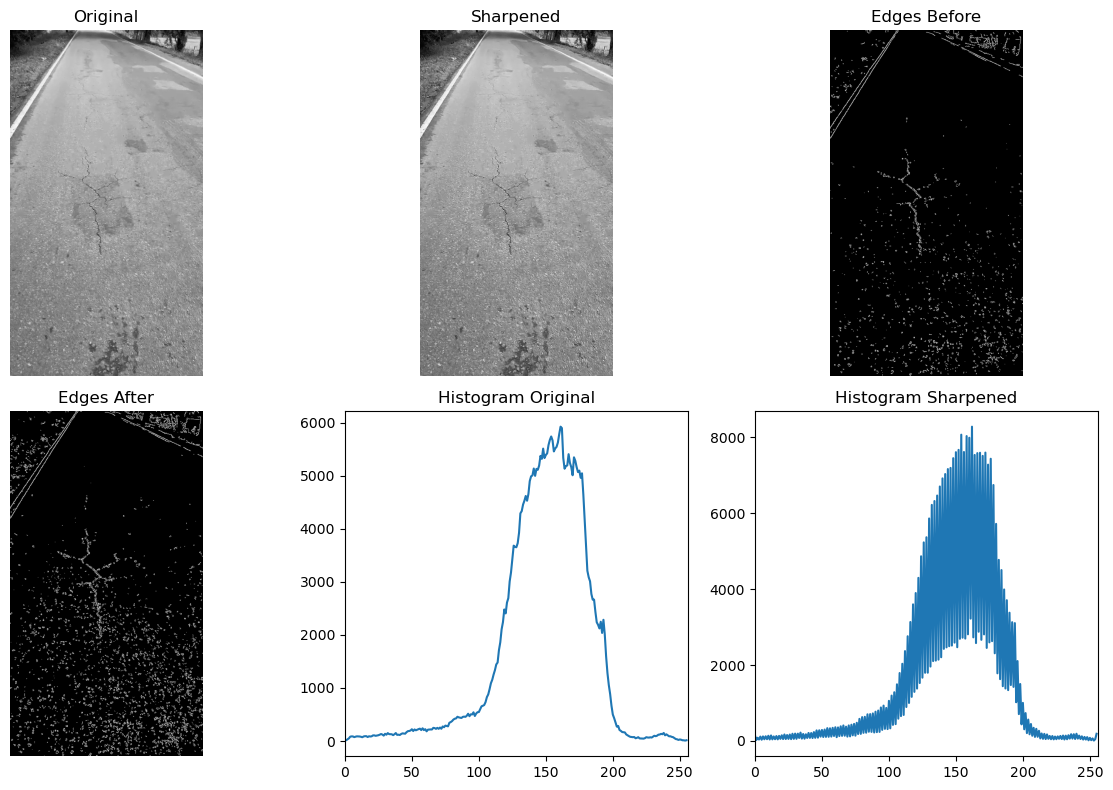

frame_0002.jpg | 1036.89 | 2208.28


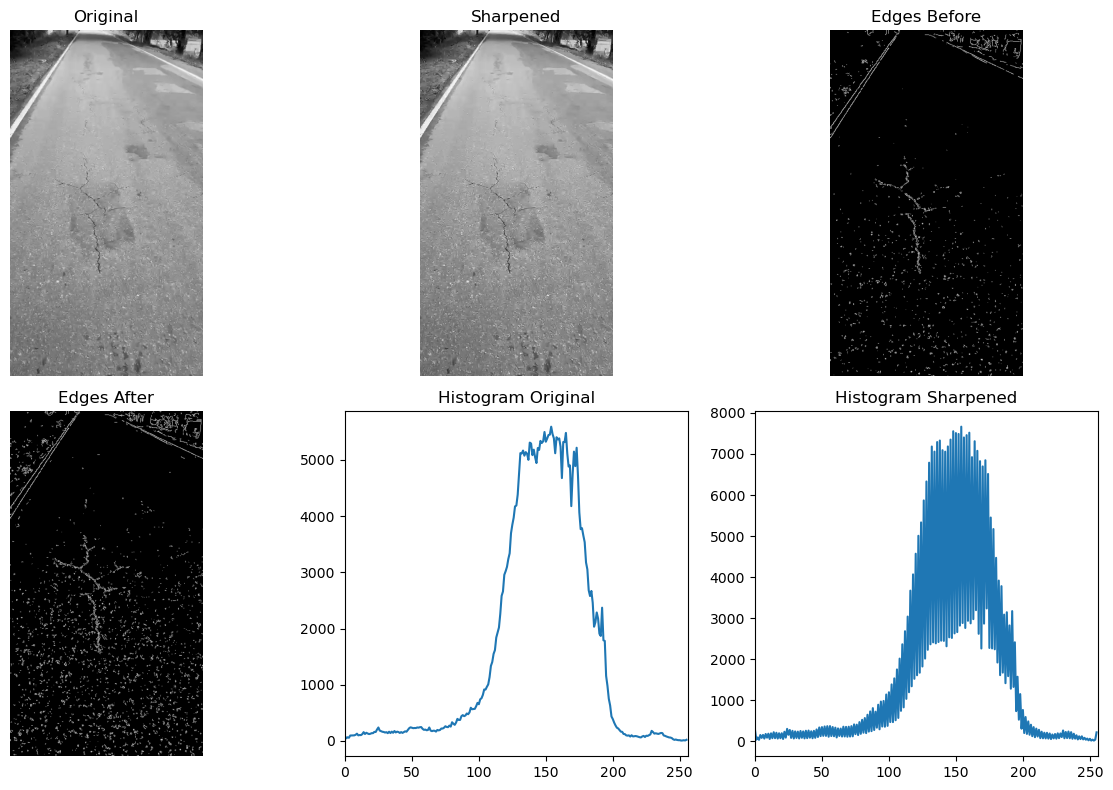

frame_0003.jpg | 373.78 | 750.55


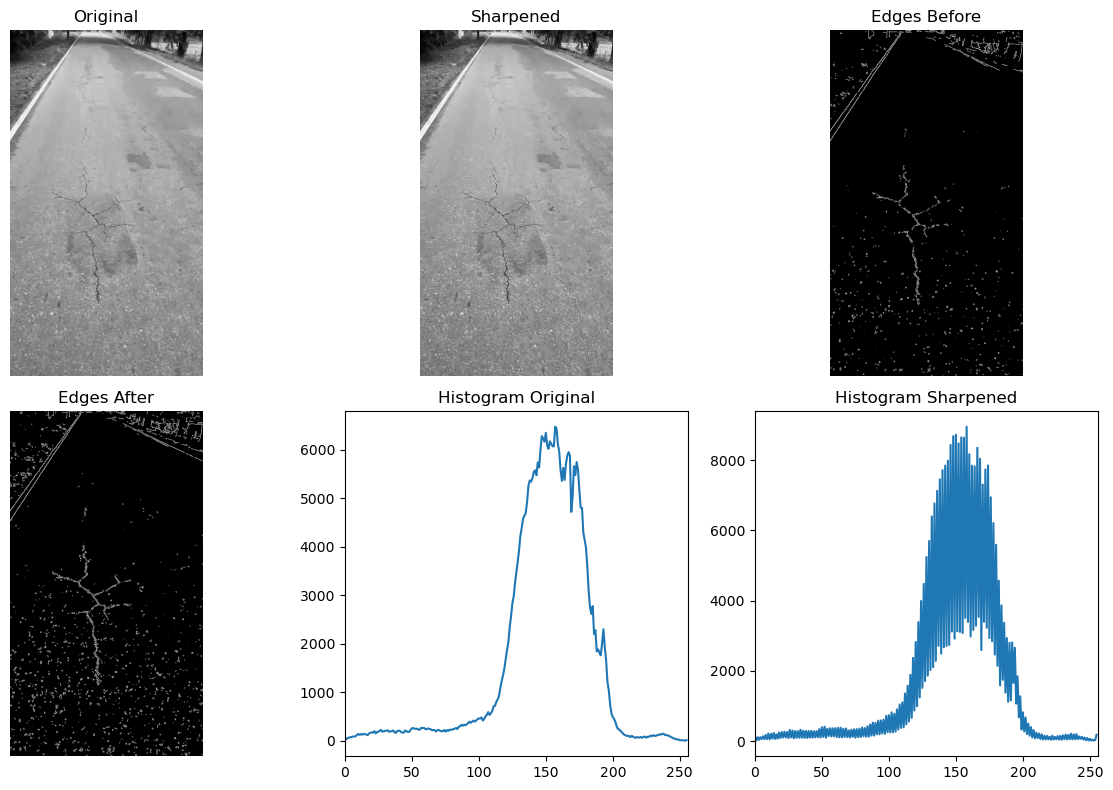

frame_0004.jpg | 841.20 | 1780.79


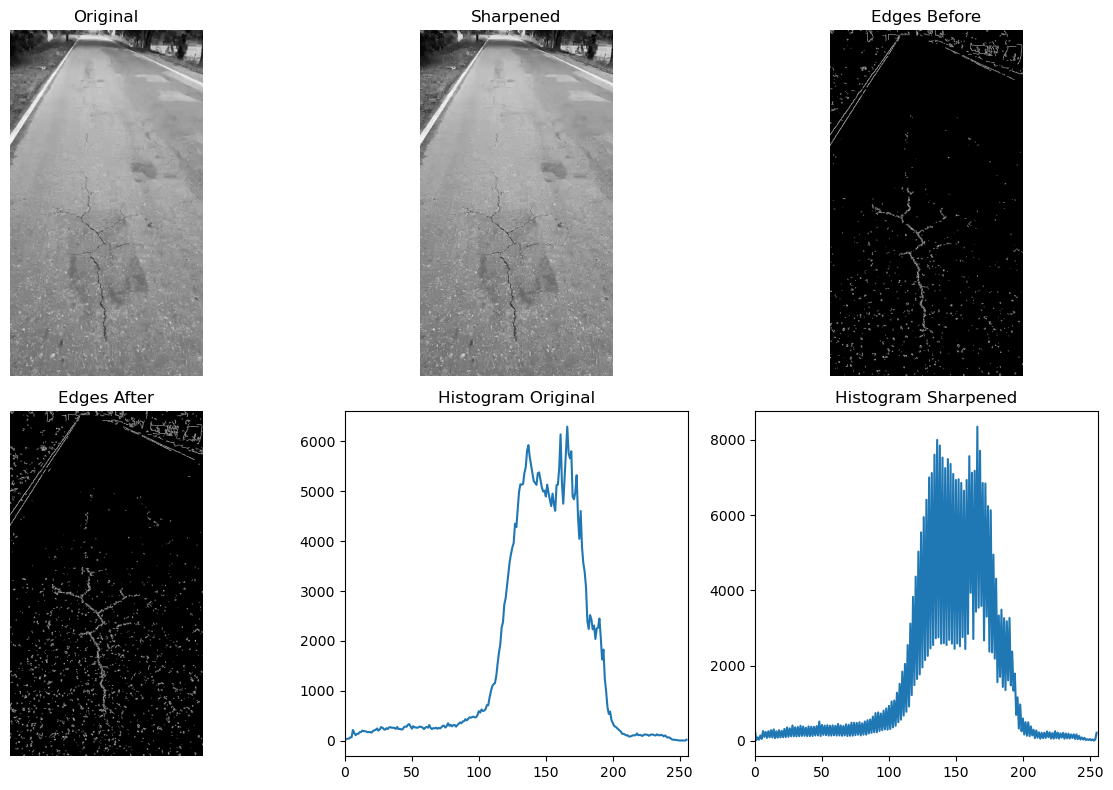

frame_0005.jpg | 364.66 | 731.10


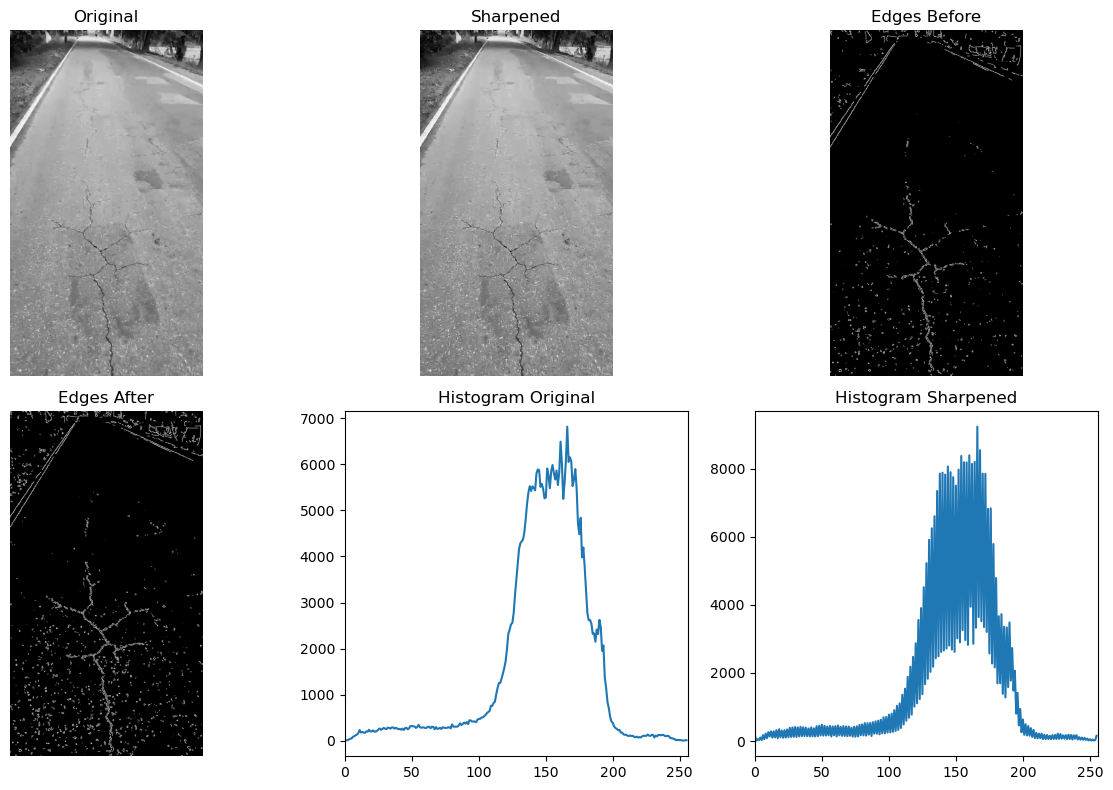

frame_0006.jpg | 987.94 | 2089.37


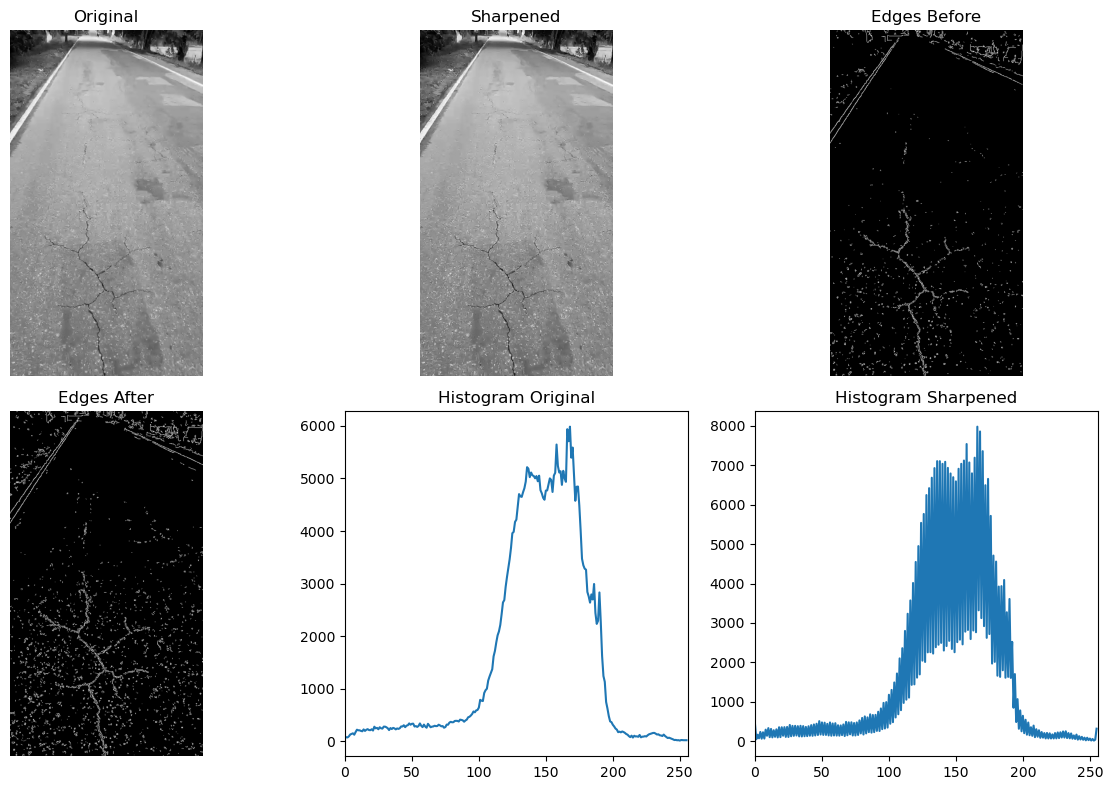

frame_0007.jpg | 389.34 | 778.23


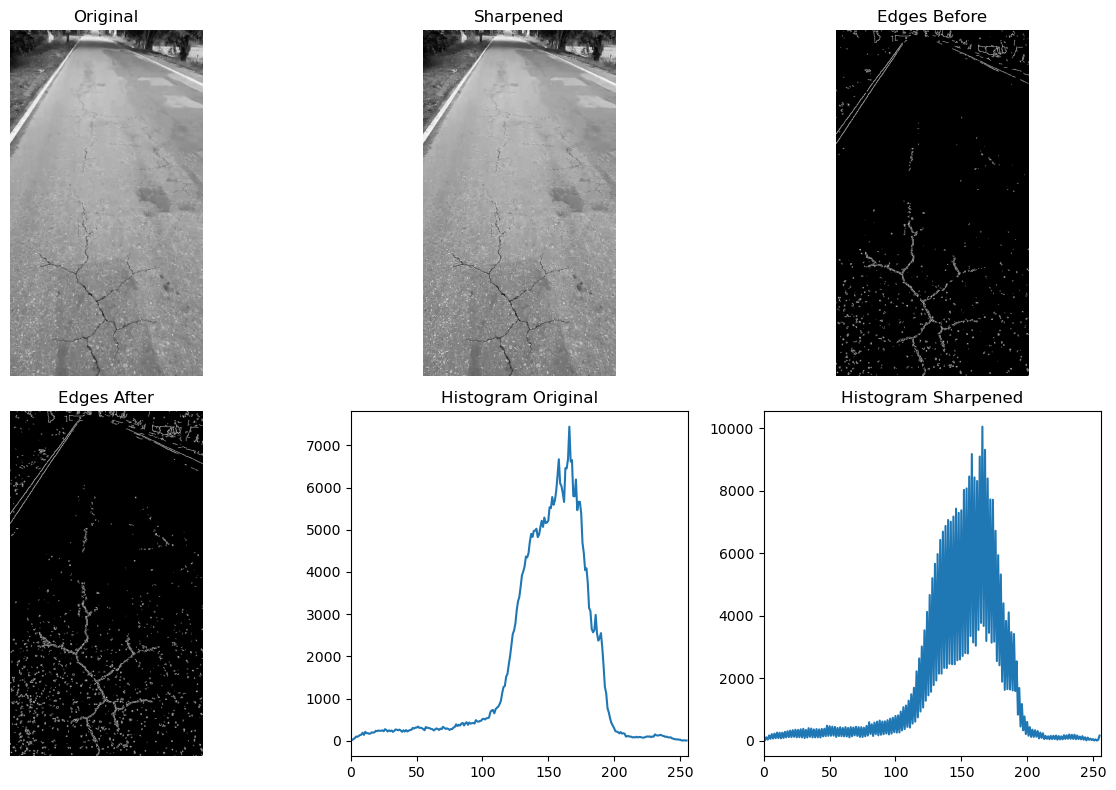

frame_0008.jpg | 1189.15 | 2529.47


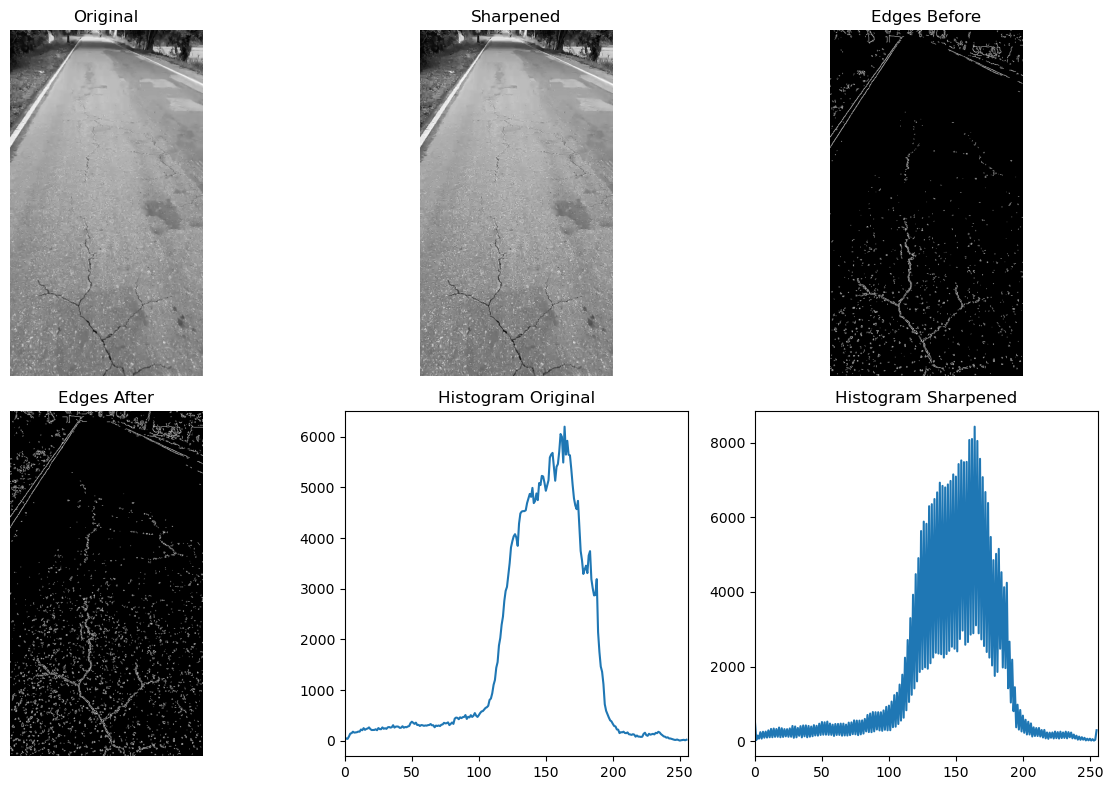

frame_0009.jpg | 412.27 | 823.81


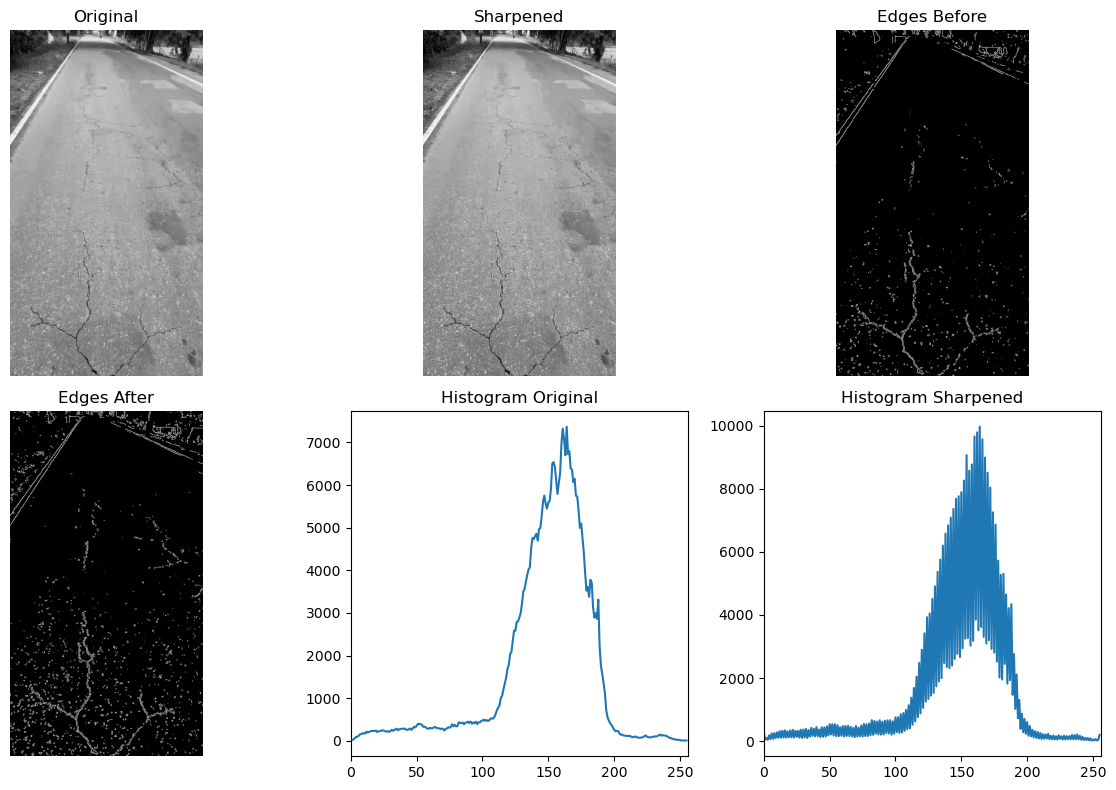

frame_0010.jpg | 1009.43 | 2139.72


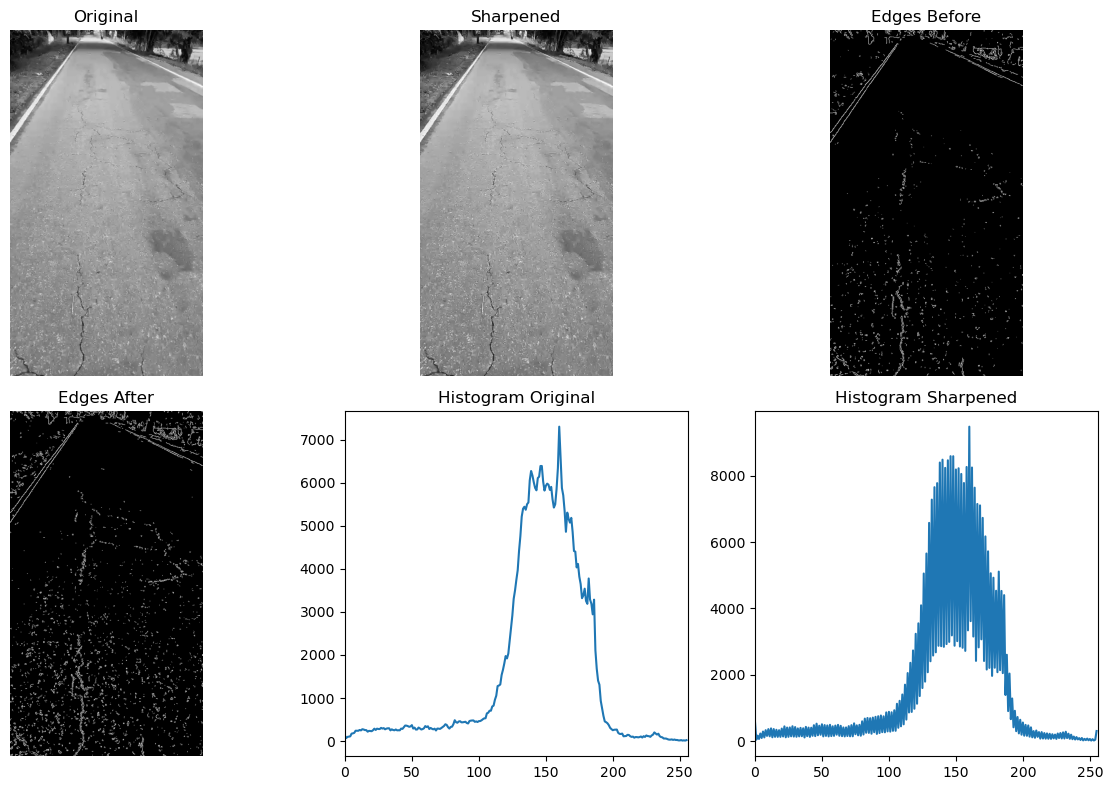

frame_0011.jpg | 357.51 | 714.77


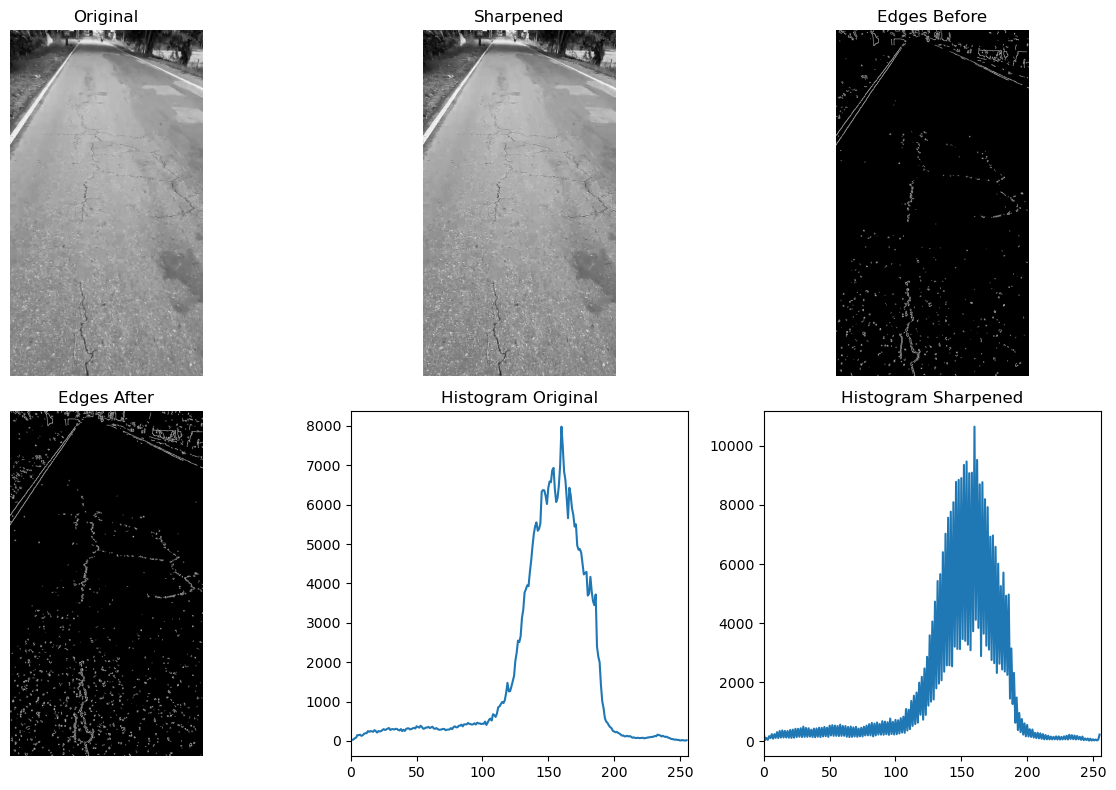

frame_0012.jpg | 808.85 | 1690.02


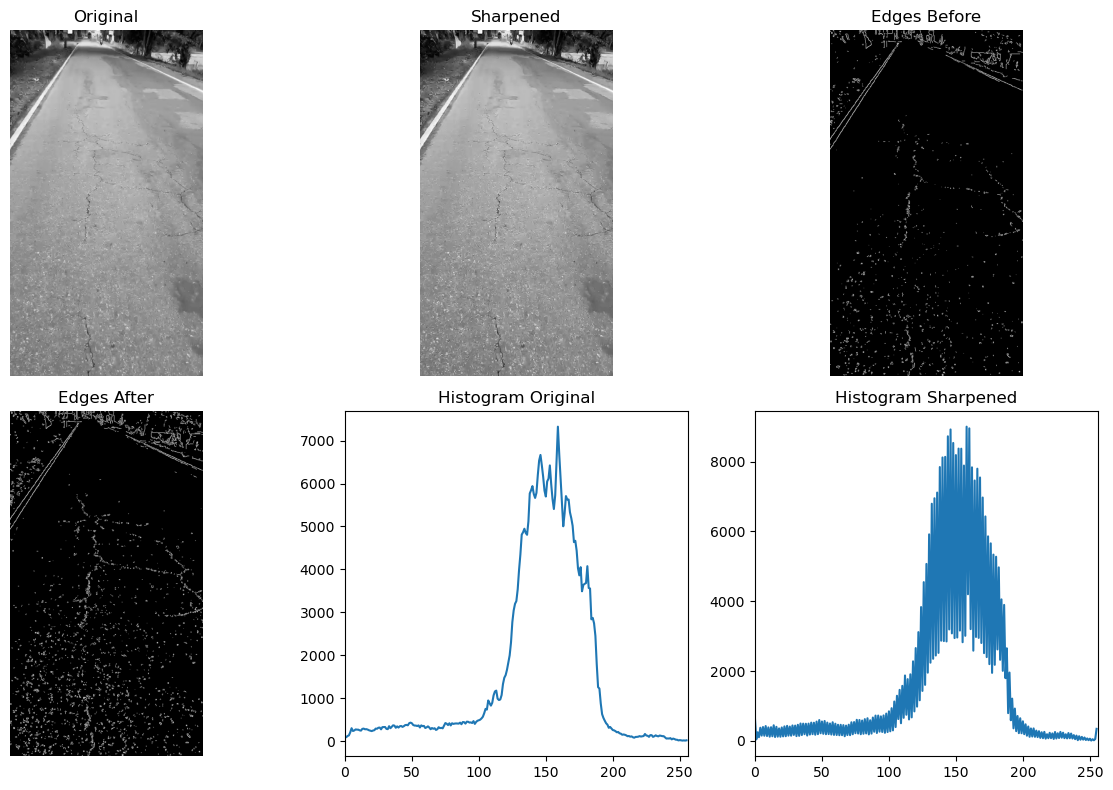

frame_0013.jpg | 401.82 | 807.43


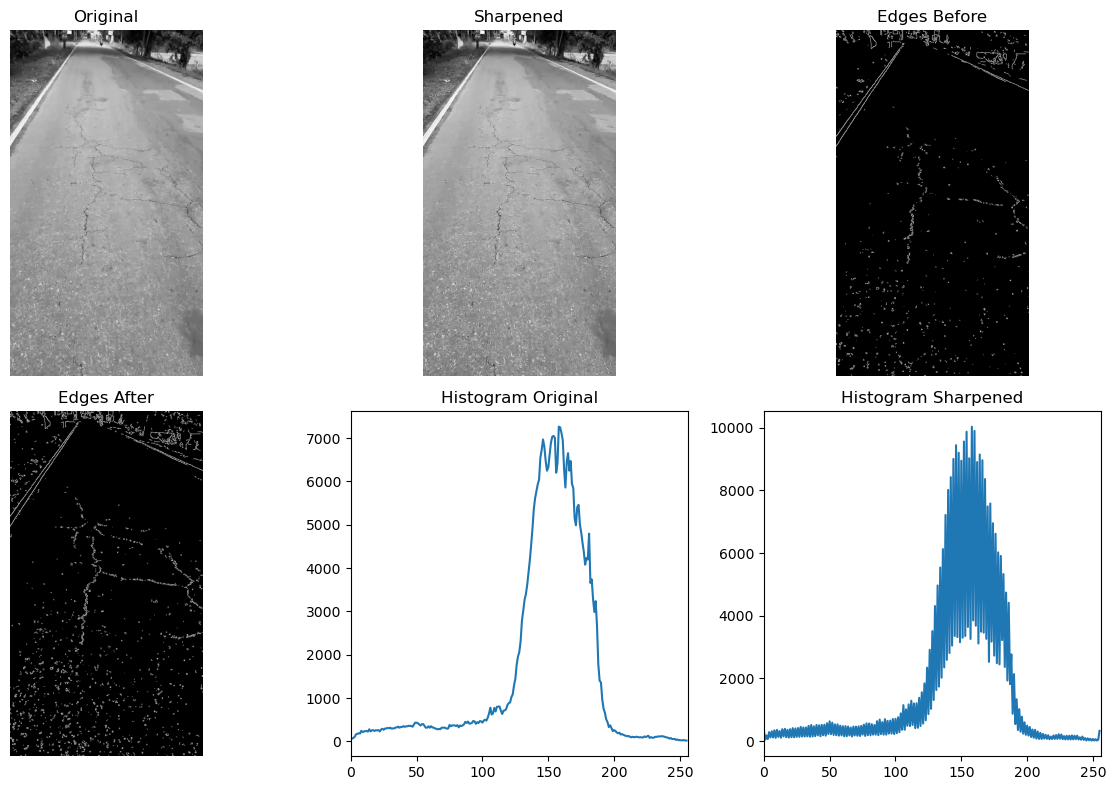

frame_0014.jpg | 824.74 | 1726.18


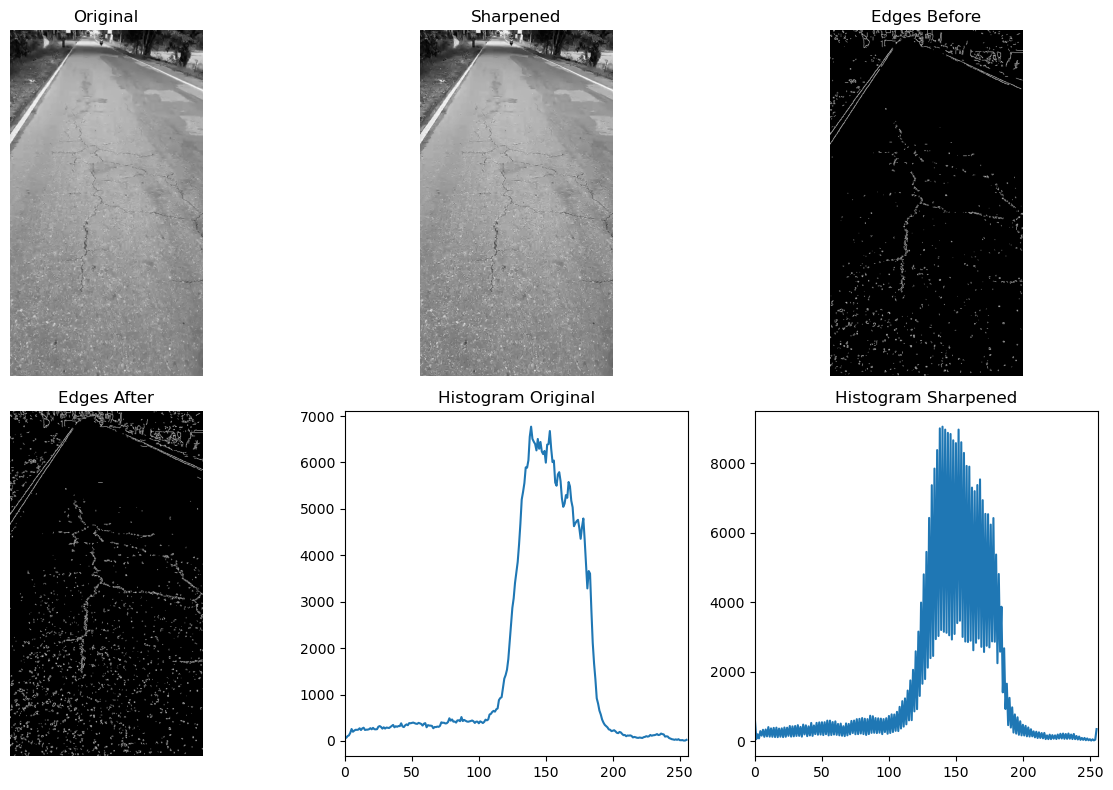

frame_0015.jpg | 455.24 | 914.88


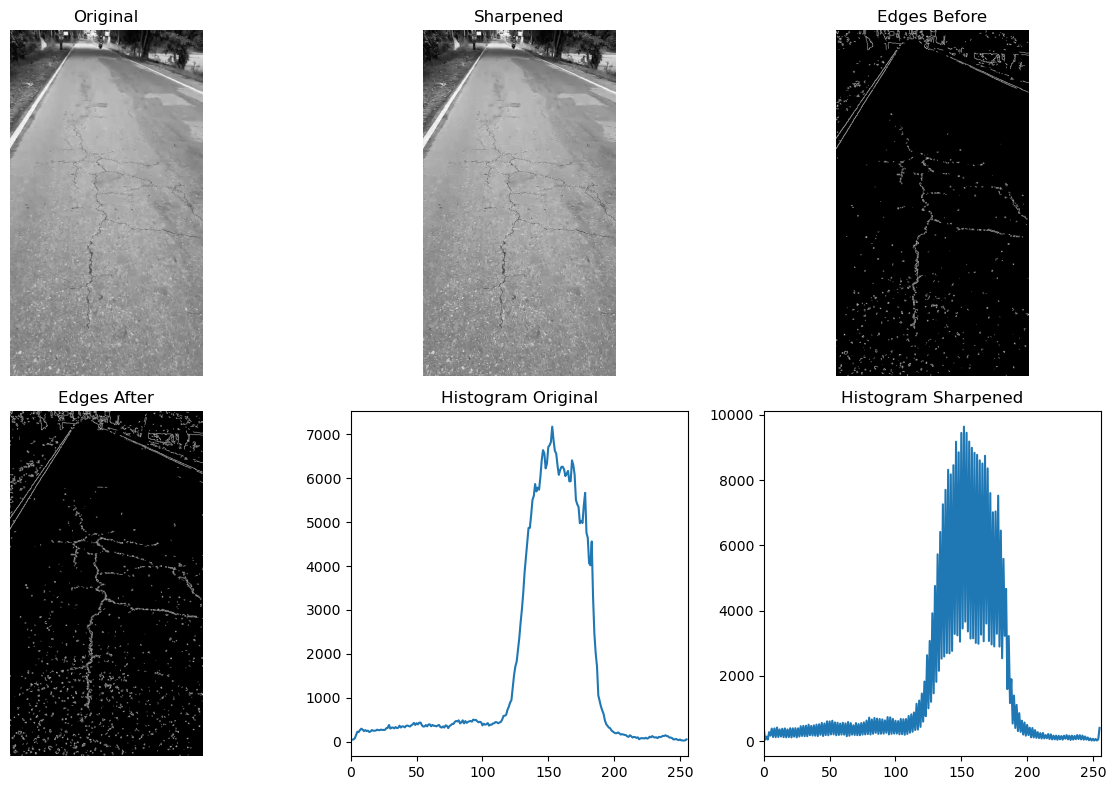

frame_0016.jpg | 851.66 | 1766.99


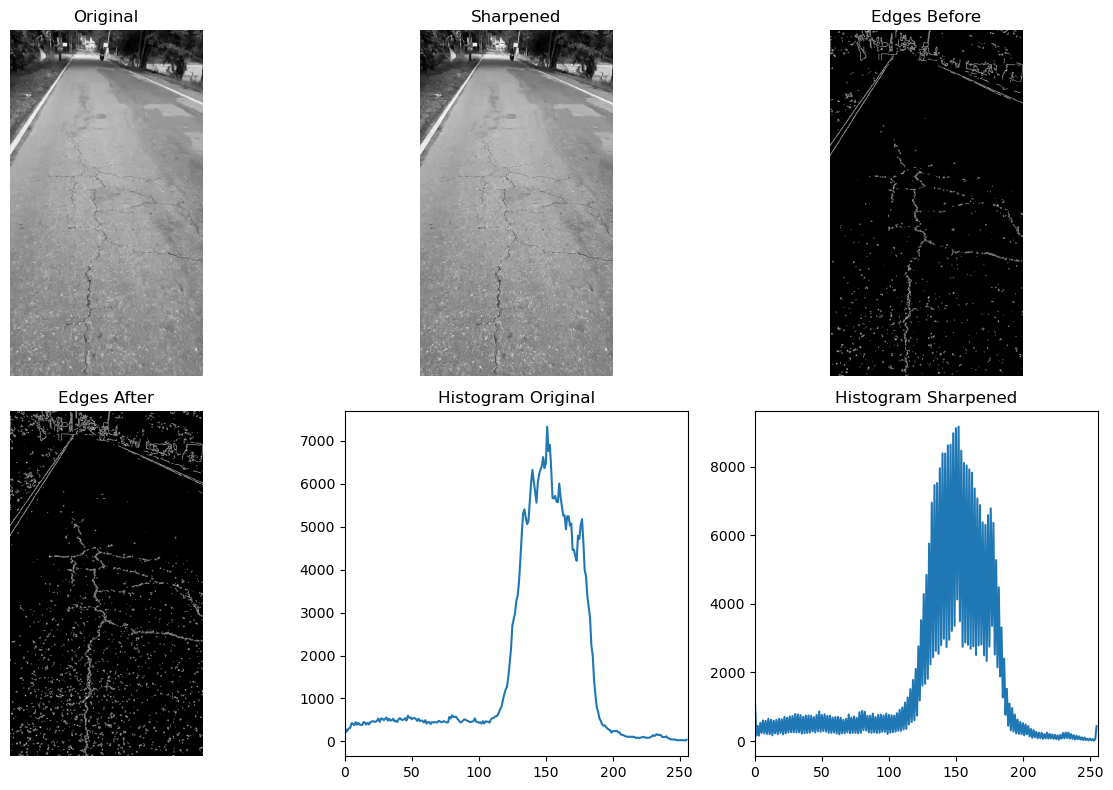

frame_0017.jpg | 508.70 | 1010.83


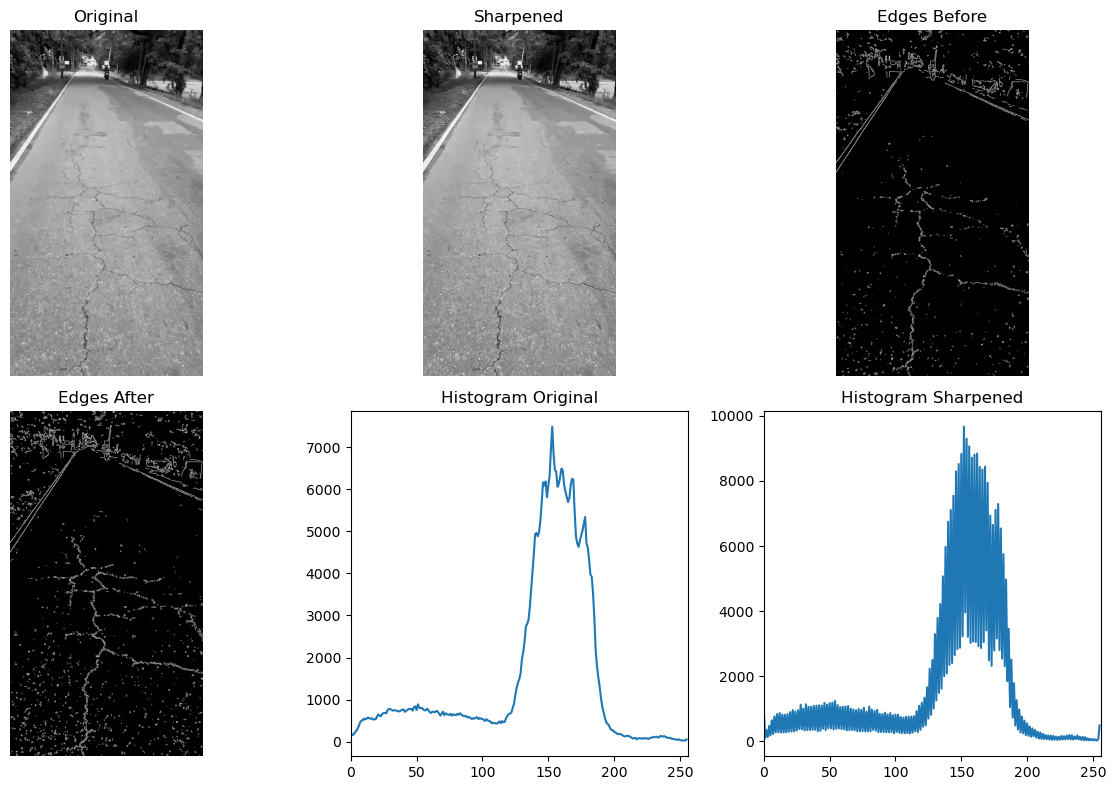


Processing Completed Successfully.


In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt


# frame extraction

video_path = "F:/Rajarata University/ICT 2403/ip_project/Transvers_cracks_2.mp4"
frames_folder = "F:/Rajarata University/ICT 2403/ip_project/framesOfTransversCracks"
os.makedirs(frames_folder, exist_ok=True)

vid = cv2.VideoCapture(video_path)

if not vid.isOpened():
    print("Error: Cannot open video.")
    exit()

frame_count = 0
saved_count = 0

while True:
    ret, frame = vid.read()
    if not ret:
        break

    # Save every 30th frame
    if frame_count % 30 == 0:
        frame_name = os.path.join(frames_folder, f"frame_{saved_count:04d}.jpg")
        cv2.imwrite(frame_name, frame)
        saved_count += 1

    frame_count += 1

width = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_rate = int(vid.get(cv2.CAP_PROP_FPS))

vid.release()

print("Video Width:", width)
print("Video Height:", height)
print("Frame Rate:", frame_rate)
print("Total Extracted Frames:", saved_count)


# blur detection function

def measure_blur(image):
    laplacian = cv2.Laplacian(image, cv2.CV_64F)
    return laplacian.var()


# sharpening function

def sharpen_image(image):
    gaussian = cv2.GaussianBlur(image, (5,5), 0)
    sharpened = cv2.addWeighted(image, 1.5, gaussian, -0.5, 0)
    return sharpened


input_folder = frames_folder
output_folder = os.path.join(frames_folder, "sharpened")
os.makedirs(output_folder, exist_ok=True)

frame_files = sorted([f for f in os.listdir(input_folder) if f.endswith(".jpg")])

print("\nFrame | Blur Before | Blur After")
print("------------------------------------------------")

for file in frame_files[:30]: 
    img_path = os.path.join(input_folder, file)
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        continue

    # Measure blur BEFORE
    blur_before = measure_blur(image)

    # Apply sharpening
    sharpened = sharpen_image(image)

    # Measure blur AFTER
    blur_after = measure_blur(sharpened)

    print(f"{file} | {blur_before:.2f} | {blur_after:.2f}")

    # Save sharpened image
    out_path = os.path.join(output_folder, f"sharpened_{file}")
    cv2.imwrite(out_path, sharpened)


    # edge comparison

    edges_before = cv2.Canny(image, 250, 300)
    edges_after = cv2.Canny(sharpened, 250, 300)

    # histogram function

    def plot_histogram(img, title):
        hist = cv2.calcHist([img], [0], None, [256], [0,256])
        plt.plot(hist)
        plt.title(title)
        plt.xlim([0,256])

   
    # display results

    plt.figure(figsize=(12,8))

    plt.subplot(2,3,1)
    plt.imshow(image, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,3,2)
    plt.imshow(sharpened, cmap='gray')
    plt.title("Sharpened")
    plt.axis("off")

    plt.subplot(2,3,3)
    plt.imshow(edges_before, cmap='gray')
    plt.title("Edges Before")
    plt.axis("off")

    plt.subplot(2,3,4)
    plt.imshow(edges_after, cmap='gray')
    plt.title("Edges After")
    plt.axis("off")

    plt.subplot(2,3,5)
    plot_histogram(image, "Histogram Original")

    plt.subplot(2,3,6)
    plot_histogram(sharpened, "Histogram Sharpened")

    plt.tight_layout()
    plt.show()

print("\nProcessing Completed Successfully.")